In [18]:
# Load environment variables and set up auto-reload
from pathlib import Path
from dotenv import load_dotenv

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("Could not find project root via pyproject.toml")

PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / ".env.local", override=True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from notebooks.utils import show_prompt
from prompts import clarify_with_user_instructions
show_prompt(clarify_with_user_instructions, "Clarify with User Instructions")

╭──────────────────────────────────────── Clarify with User Instructions ─────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  These are the messages that have been exchanged so far from the user asking for economic database series       │
│  onboarding:                                                                                                    │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
│  You have access to web_search tool:                                                                            │
│  1. **web_search**: For conducting web searches to gather information in order to ask more informed clarifying  │
│  questions to the user.                                                                                         │
│                                                                                                                 │
│  Your task is to assess whether the user has provided enough information to identify the exact economic or      │
│  financial data series they want to add, retrieve, or research for the macro database.                          │
│                                                                                                                 │
│  Core criterias:                                                                                                │
│  1. The requested item must be economic or financial data.                                                      │
│  - Examples: macroeconomic indicators, financial market prices, rates, spreads, indices, fund data, company     │
│  financials, exchange rates, commodities, credit data, monetary data, fiscal data.                              │
│  - If the request is not clearly economic or financial data, ask the user to clarify or restate the request in  │
│  terms of a data series.                                                                                        │
│  2. The user must provide enough information to identify the exact data series without guessing.                │
│  It is sufficient if the user provides a unique series code, ticker, provider URL, database identifier, or      │
│  other exact identifier.                                                                                        │
│  - Example: "FRED BAMLH0A0HYM2" is sufficient because the exact FRED series can be identified.                  │
│  - Example: "this FRED URL: " is sufficient if the URL points to a specific series.                             │
│  - Example: "USDHKD exchange rate from Alpha Vantage" may be sufficient if the provider has a clear unique FX   │
│  pair endpoint.                                                                                                 │
│  3. A broad economic concept is not sufficient when multiple variants could match.                              │
│  - Example: "US CPI from FRED" is not sufficient because CPI has multiple variants, such as headline vs core,   │
│  CPI-U vs other population groups, seasonally adjusted vs not seasonally adjusted, index level vs inflation     │
│  rate.                                                                                                          │
│  - Example: "US unemployment rate" may be ambiguous un

In [20]:
from prompts import transform_messages_into_series_brief_prompt

show_prompt(
    transform_messages_into_series_brief_prompt,
    "Transform Messages Into Series Brief Prompt",
)

╭────────────────────────────────── Transform Messages Into Series Brief Prompt ──────────────────────────────────╮
│                                                                                                                 │
│  You will be given a set of messages that have been exchanged so far between yourself and the user.             │
│                                                                                                                 │
│  Your job is to write a self-contained descriptive series onboarding handoff brief.                             │
│                                                                                                                 │
│  The messages that have been exchanged so far between yourself and the user are:                                │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│  This brief is not a research report and should not try to fully populate database fields. It should preserve   │
│  the user's intended series scope, source, specific requirements, and provide enough descriptive information    │
│  for a downstream agent to draft a governance-compatible series registration proposal.                          │
│                                                                                                                 │
│  You have access to web_search tool:                                                                            │
│  1. **web_search**: For conducting web searches to gather information                                           │
│                                                                                                                 │
│  Guidelines:                                                                                                    │
│                                                                                                                 │
│  1. Capture the user's requested series                                                                         │
│                                                                                                                 │
│  * State the data series or set of series the user wants to onboard.                                            │
│  * Preserve exact identifiers exactly as written, including provider names, URLs, series codes, tickers, API    │
│  functions, or source pages.                                                                                    │
│  * If the source or identifier was agreed in the conversation, make that clear.                                 │
│  * If the request is still ambiguous, state the ambiguity clearly.                                              │
│                                                                                                                 │
│  2. Describe the series in useful onboarding language                                                           │
│     Include any descriptive information available from the conversation, such as:                               │
│  * What the series measures                                                                                     │
│  * Geography, market, country, region, sector, or asset class                                                   │
│  * Provider or source                                                                                           │
│  * Variant or definition, if stated                                                                             │
│  * Frequency, units, currency, seasonal adjustment, or

In [21]:
%%writefile state_scope.py

"""State Definitions and Pydantic Schemas for Research Scoping.

This defines the state objects and structured schemas used for
the research agent scoping workflow, including researcher state management and output schemas.
"""

from typing_extensions import Optional, List

from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

# ===== STATE DEFINITIONS =====

class AgentInputState(MessagesState):
    """Input state for the full agent - only contains messages from user input."""
    pass

class AgentState(MessagesState):
    """
    Main state for the full multi-agent research system.
    
    Extends MessagesState with additional fields for research coordination.
    Note: Some fields are duplicated across different state classes for proper
    state management between subgraphs and the main workflow.
    """

    # Series brief generated from user conversation history
    series_brief: Optional[str]
    need_clarification: Optional[bool]
    clarification_question: Optional[str]
    clarification_reasons: List[str]
    

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decision and questions."""
    
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the onboarding series scope",
    )
    verification: str = Field(
        description="Verify message that we will start series onboarding after the user has provided the necessary information.",
    )

class SeriesBrief(BaseModel):
    """Schema for structured series brief generation."""
    
    series_brief: str = Field(
        description="A brief description of the economic or financial data series to be onboarded.",
    )
    needs_clarification: bool = Field(
        description="Whether clarification is needed before a safe brief can be written.",
    )
    clarification_question: str = Field(
        description="One concise question to ask the user if clarification is needed. Empty otherwise.",
    )
    clarification_reasons: List[str] = Field(
        default_factory=list,
        description="Short reasons why clarification is needed.",
    )

Overwriting state_scope.py


In [22]:
%%writefile onboarding_scope.py

"""Series onboarding scoping workflow.

This module implements the scoping phase of the onboarding workflow, where we:
1. Decide whether the user's request needs clarification
2. Generate a structured series brief from the conversation

The workflow uses structured output so the clarification decision and
series brief generation remain deterministic and easy to inspect.
"""

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, get_buffer_string
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command

try:
    from macro_foundry.onboarding_agent.prompts import (
        clarify_with_user_instructions,
        transform_messages_into_series_brief_prompt,
    )
    from macro_foundry.onboarding_agent.state_scope import (
        AgentInputState,
        AgentState,
        ClarifyWithUser,
        SeriesBrief,
    )
except ModuleNotFoundError:
    from prompts import (
        clarify_with_user_instructions,
        transform_messages_into_series_brief_prompt,
    )
    from state_scope import AgentInputState, AgentState, ClarifyWithUser, SeriesBrief


def get_model():
    """Build the model lazily so importing the module does not require credentials."""
    return init_chat_model(model="openai:gpt-5.4", temperature=1, use_responses_api=True)


def clarify_with_user(state: AgentState) -> Command[Literal["write_series_brief", "__end__"]]:
    """Check whether the user has specified enough to identify the target series."""
    structured_output_model = get_model().with_structured_output(
        ClarifyWithUser,
        tools=[{"type": "web_search"}],
    )


    response = structured_output_model.invoke([
        HumanMessage(
            content=clarify_with_user_instructions.format(
                messages=get_buffer_string(messages=state["messages"]),
            )
        )
    ])

    if response.need_clarification:
        return Command(
            goto=END,
            update={
                "need_clarification": True,
                "clarification_question": response.question,
                "clarification_reasons": state.get("clarification_reasons", []),
                "messages": [AIMessage(content=response.question)],
            },
        )

    return Command(
        goto="write_series_brief",
        update={
            "need_clarification": False,
            "clarification_question": "",
            "clarification_reasons": [],
            "messages": [AIMessage(content=response.verification)],
        },
    )


def write_series_brief(state: AgentState) -> Command[Literal["clarify_with_user", "__end__"]]:
    """Turn the conversation history into a concise onboarding-ready series brief."""

    structured_output_model = get_model().with_structured_output(
        SeriesBrief,
        tools=[{"type": "web_search"}],
    )


    response = structured_output_model.invoke([
        HumanMessage(
            content=transform_messages_into_series_brief_prompt.format(
                messages=get_buffer_string(state.get("messages", [])),
            )
        )
    ])

    if response.needs_clarification:
        reasons = "\n".join(f"- {reason}" for reason in response.clarification_reasons)
        blocker_context = (
            "The series brief quality check found that clarification is still needed.\n"
            f"{reasons}"
        )
        return Command(
            goto="clarify_with_user",
            update={
                "series_brief": "",
                "need_clarification": True,
                "clarification_question": response.clarification_question,
                "clarification_reasons": response.clarification_reasons,
                "messages": [AIMessage(content=blocker_context)],
            },
        )

    return Command(
        goto=END,
        update={
            "series_brief": response.series_brief,
            "need_clarification": False,
            "clarification_question": "",
            "clarification_reasons": [],
        },
    )


series_scope_builder = StateGraph(AgentState, input_schema=AgentInputState)
series_scope_builder.add_node("clarify_with_user", clarify_with_user)
series_scope_builder.add_node(
    "write_series_brief",
    write_series_brief,
    destinations=("clarify_with_user", END),
)
series_scope_builder.add_edge(START, "clarify_with_user")

scope_series_onboarding = series_scope_builder.compile()


Overwriting onboarding_scope.py


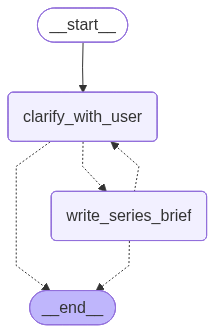

In [23]:
# Compile with in-memory checkpointer to test in notebook
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from onboarding_scope import series_scope_builder

checkpointer = InMemorySaver()
scope = series_scope_builder.compile(checkpointer=checkpointer)
display(Image(scope.get_graph(xray=True).draw_mermaid_png()))

In [24]:
# Run the workflow
from notebooks.utils import format_messages
from langchain_core.messages import HumanMessage

thread = {"configurable": {"thread_id": "1"}}
result = scope.invoke(
    {"messages": [HumanMessage(content="I want to onboard US core CPI series CPIAUCSL")]},
    config=thread,
)
format_messages(result["messages"])


/Users/leodai/Development/macro_foundry/.venv/lib/python3.14/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(PydanticSerializationUnexpectedValue: Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ClarifyWithUser(need_clar... on that exact series.'), input_type=ClarifyWithUser]
PydanticSerializationUnexpectedValue: Expected `ResponseOutputRefusal` - serialized value may not be as expected [field_name='content', input_value=ParsedResponseOutputText[...on that exact series.')), input_type=ParsedResponseOutputText[TypeVar]])
  PydanticSerializationUnexpectedValue(Expected `ParsedResponseFunctionToolCall` - serialized value may not be as expected [field_name='output', input_value=ParsedResponseOutputMessa...', phase='final_answer'), input_type=ParsedResponseOutputMessage[TypeVar]])
  PydanticSerializationUnexpectedValue(Expected `ResponseFileSearchToolCall` - serialized value may

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to onboard US core CPI series CPIAUCSL                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I have enough information to proceed. You want to onboard the US core CPI series identified by FRED code        │
│ CPIAUCSL. I’ll now begin the research process based on that exact series.                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [27]:
from rich.markdown import Markdown
Markdown(result["series_brief"])

I want to onboard the U.S. CPI series identified by FRED code CPIAUCSL, as explicitly agreed in the conversation.  
The requested source/identifier is FRED: CPIAUCSL. This is a U.S. Consumer Price Index series published through    
FRED and is commonly described there as the Consumer Price Index for All Urban Consumers: All Items in U.S. City   
Average. It is a national U.S. inflation price index series for urban consumers, reported as an index rather than a
currency value, and FRED lists it as seasonally adjusted and monthly. Source reference for downstream verification:
FRED series page for CPIAUCSL, https://fred.stlouisfed.org/series/CPIAUCSL. Important note for downstream          
onboarding: the user referred to this as “US core CPI,” but the identifier provided, CPIAUCSL, corresponds to      
headline/all-items CPI rather than a core CPI exclusion measure on FRED. The onboarding request should therefore   
preserve the exact requested identifier CPIAUCSL while flagging the apparent label/identifier mismatch for         
governance review or user follow-up.

In [26]:
result

{'messages': [HumanMessage(content='I want to onboard US core CPI series CPIAUCSL', additional_kwargs={}, response_metadata={}, id='b5e98943-d4f4-48e7-98b4-49ddf442bb2a'),
  AIMessage(content='I have enough information to proceed. You want to onboard the US core CPI series identified by FRED code CPIAUCSL. I’ll now begin the research process based on that exact series.', additional_kwargs={}, response_metadata={}, id='6e98d1ba-7d6e-4036-a149-2cfc776443fc', tool_calls=[], invalid_tool_calls=[])],
 'series_brief': 'I want to onboard the U.S. CPI series identified by FRED code CPIAUCSL, as explicitly agreed in the conversation. The requested source/identifier is FRED: CPIAUCSL. This is a U.S. Consumer Price Index series published through FRED and is commonly described there as the Consumer Price Index for All Urban Consumers: All Items in U.S. City Average. It is a national U.S. inflation price index series for urban consumers, reported as an index rather than a currency value, and FRED l